#**📌** **Customer Churn Prediction : Using ML Algorithms**

# **⚡Objective**

**This notebook presents an end-to-end machine learning workflow for Customer Churn prediction,incorporating feature engineering,data cleaning and analysis,model training, and evaluation.The goal wasn't simply to maximize a metric-it was to build a model with meaningful features,strong generalization,and useful churn detection performance .**

1. Importing th required libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import ComplementNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,OrdinalEncoder
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report,precision_score,recall_score,f1_score
from sklearn.metrics import roc_auc_score , average_precision_score , confusion_matrix
from scipy.stats import uniform,randint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,BatchNormalization
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping

2. Loading the data

In [ ]:
df = pd.read_csv("/content/sample_data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

3. Exploratory Data Analysis

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


<Axes: ylabel='count'>

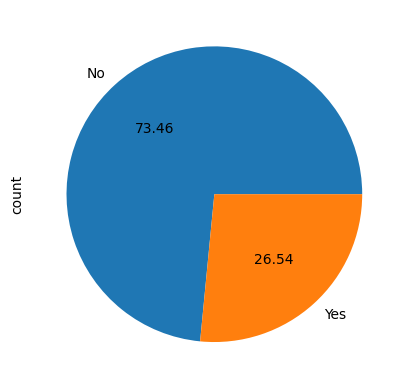

In [ ]:
df['Churn'].value_counts().plot(kind='pie',autopct='%.2f')

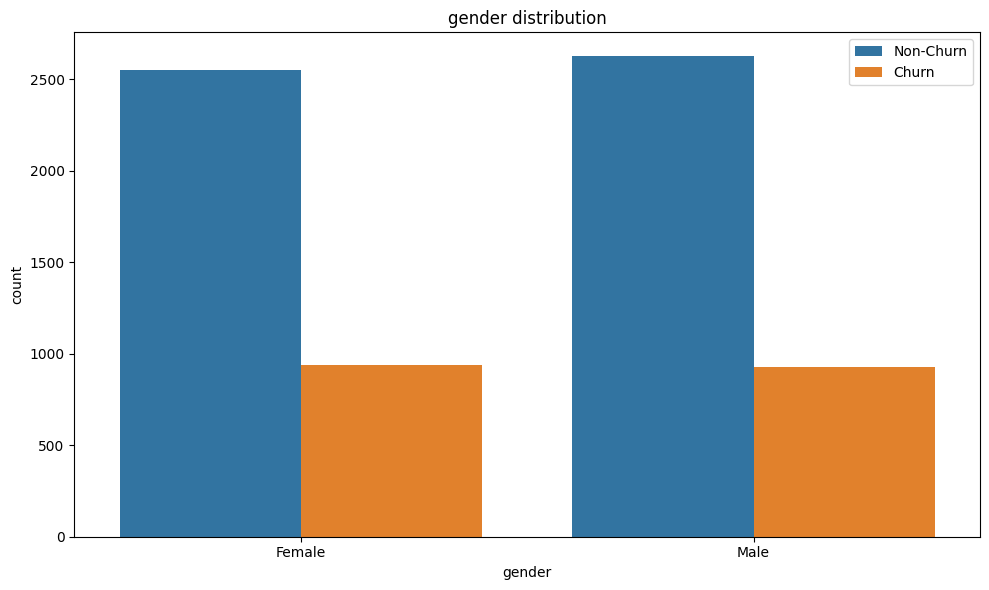

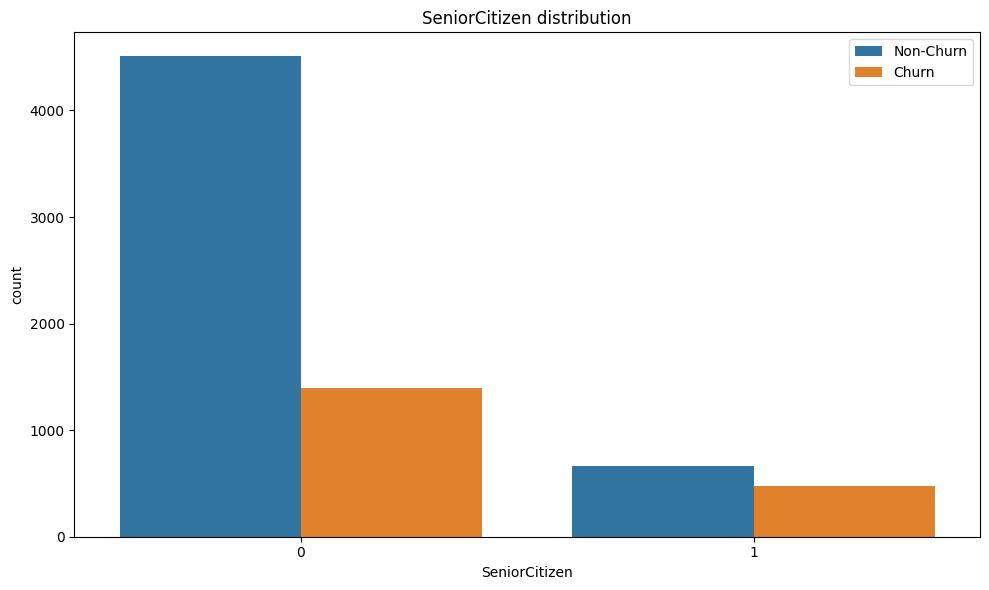

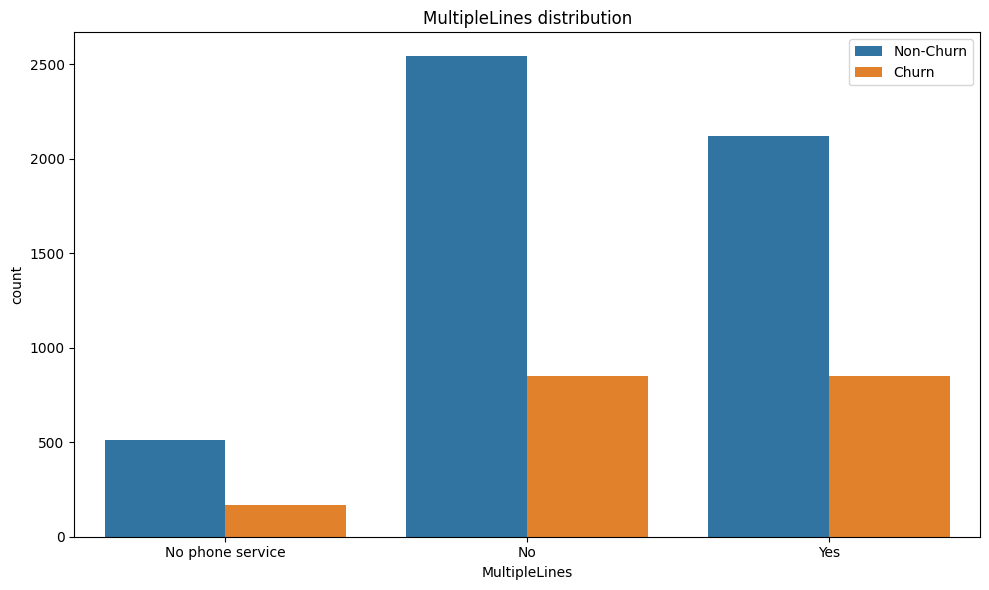

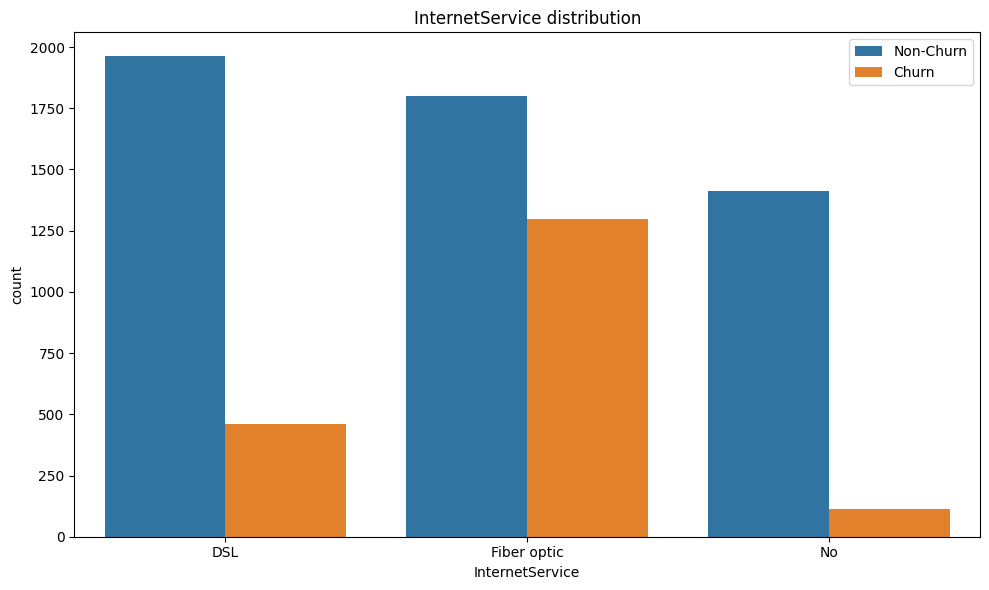

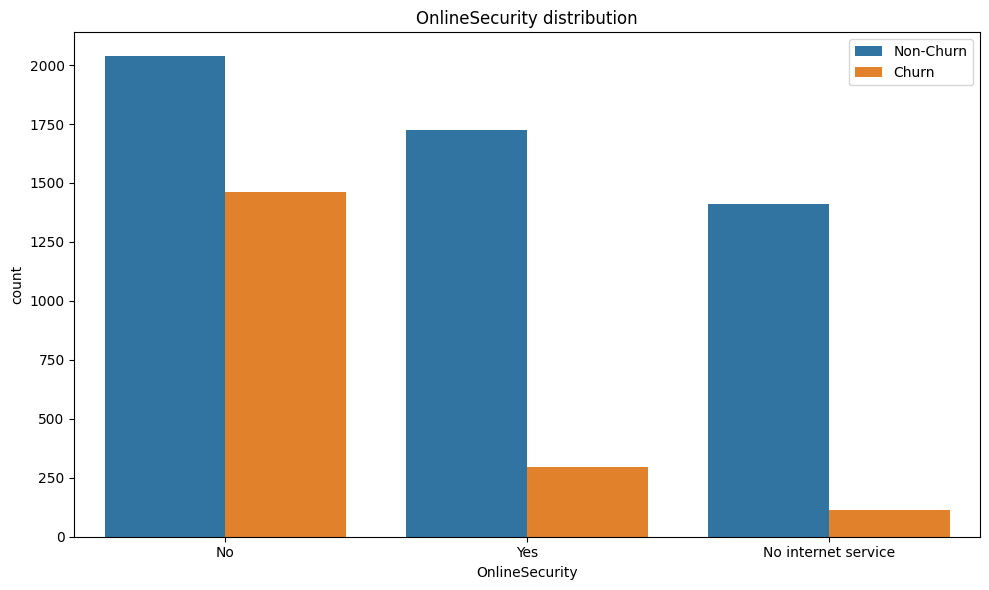

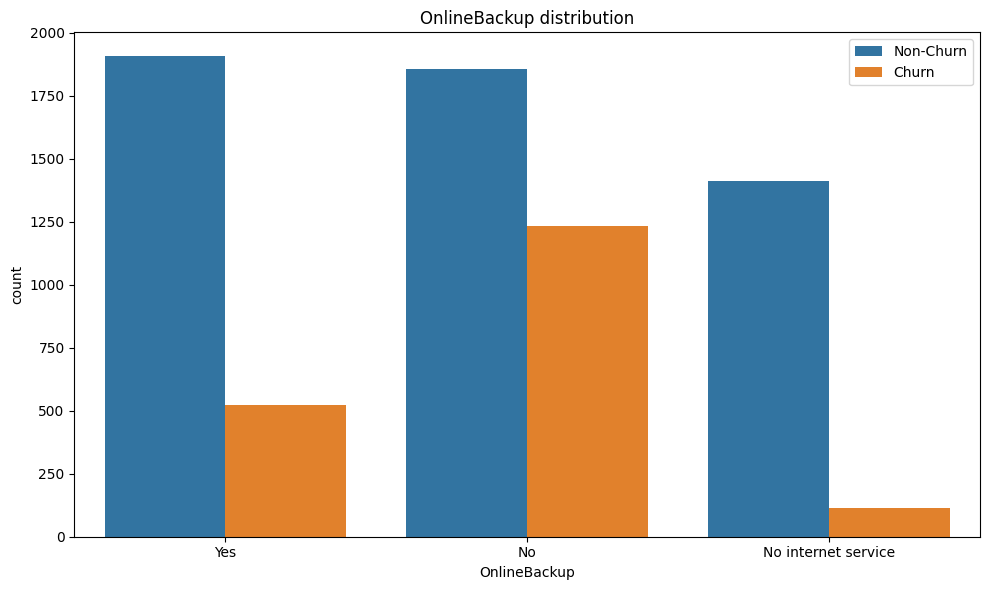

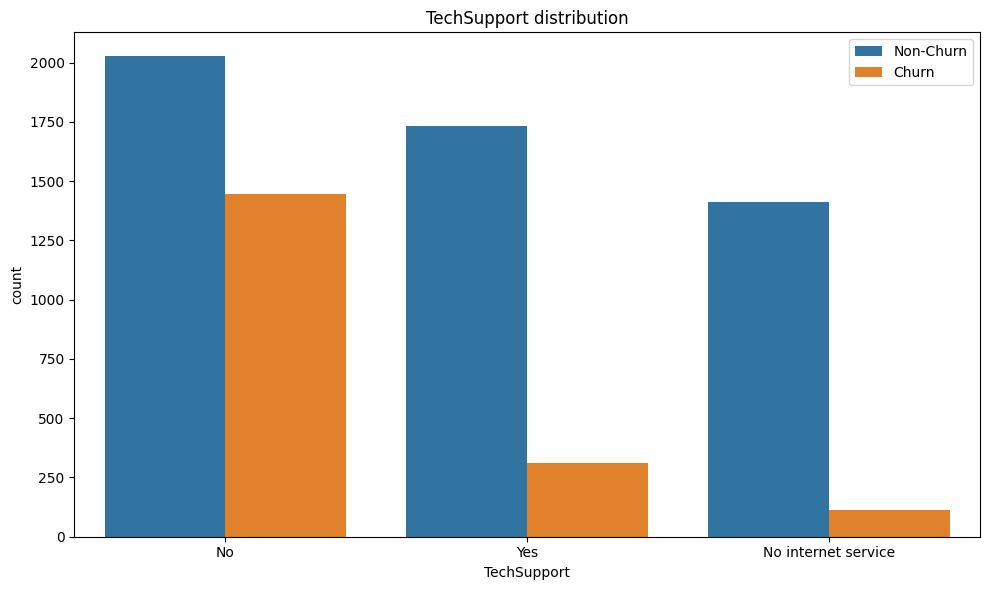

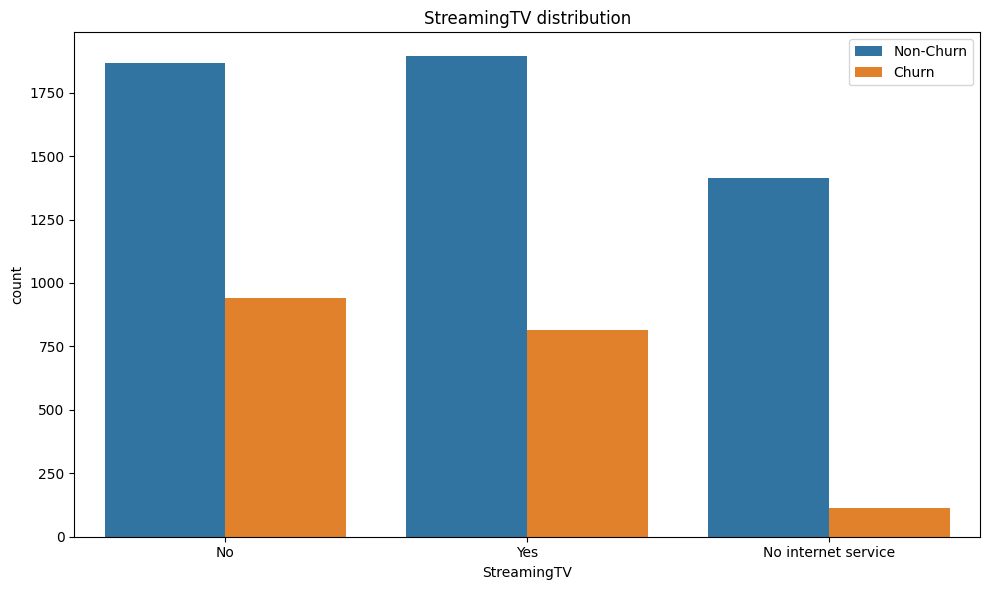

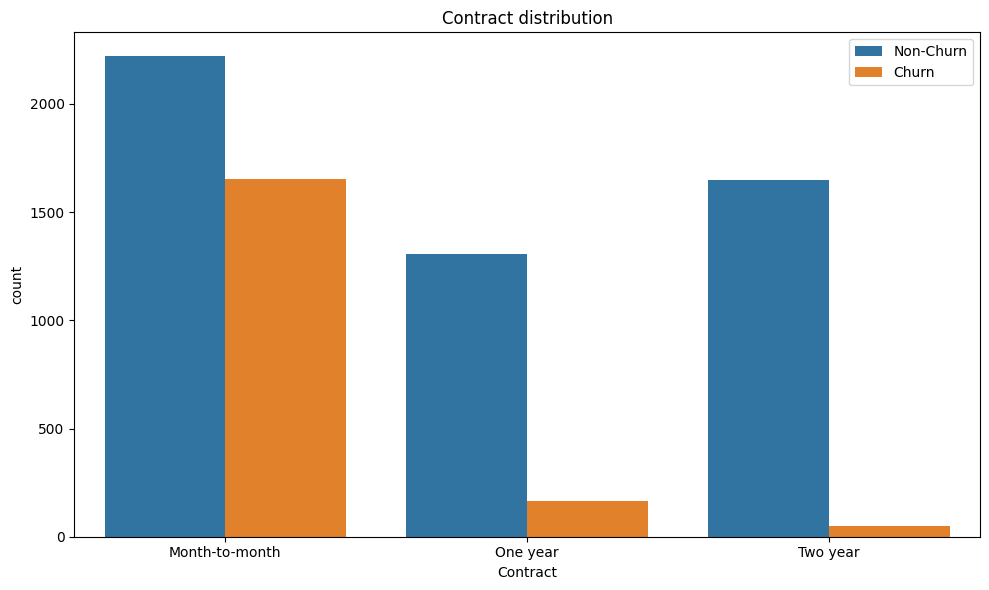

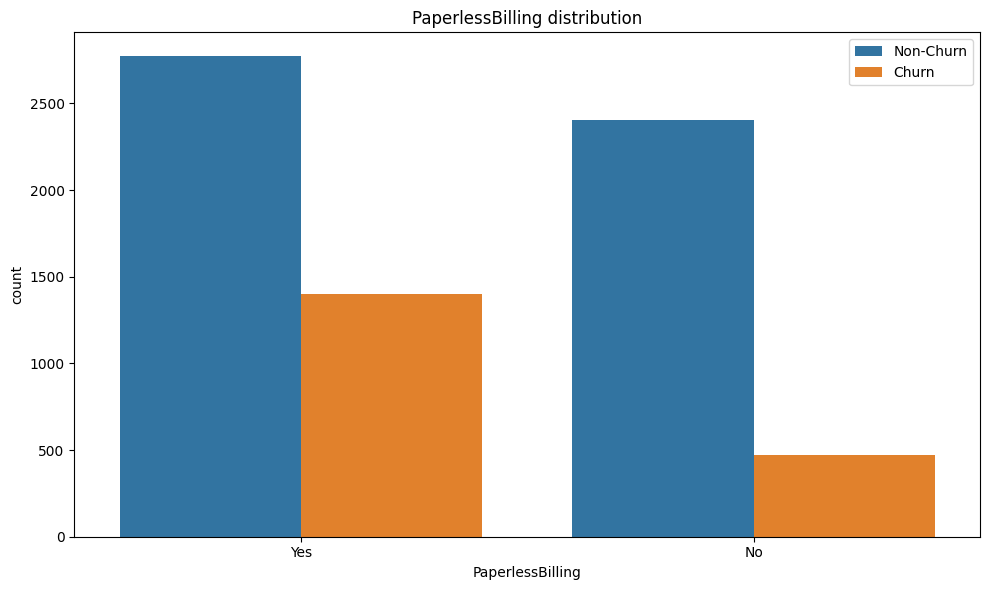

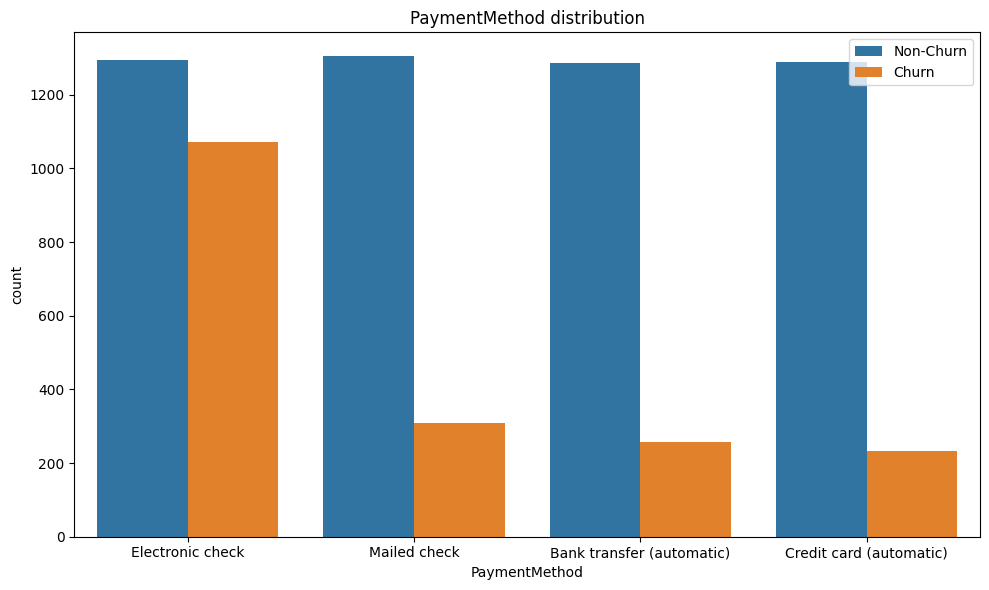

In [ ]:
cols = ([i for i in df.columns if (i != 'Churn' and i != 'tenure' and i != 'MonthlyCharges' and i != 'TotalCharges' and i != 'StreamingMovies' and i != 'DeviceProtection' and i != 'Partner' and i != 'Dependents' and i != 'customerID' and i != 'PhoneService')])
for col in cols :
  plt.figure(figsize=(10,6))
  sns.countplot(data = df , x = col , hue = 'Churn')
  plt.title(f"{col} distribution")
  plt.legend(labels=['Non-Churn','Churn'])
  plt.tight_layout()
  plt.show()

<Axes: xlabel='Contract', ylabel='tenure'>

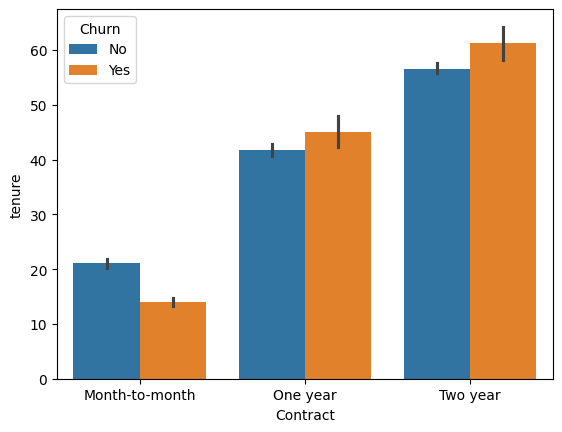

In [ ]:
sns.barplot(data=df,x='Contract',y='tenure',hue='Churn')

<Axes: xlabel='tenure'>

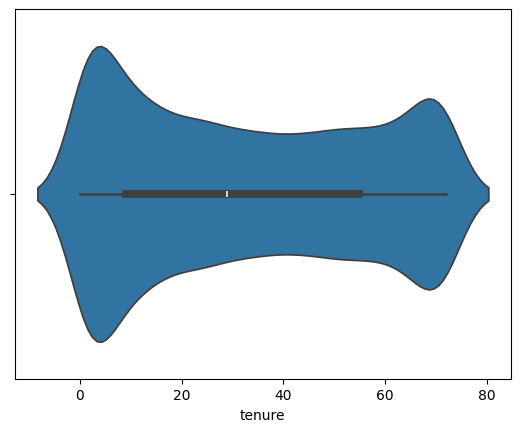

In [ ]:
sns.violinplot(x = df['tenure'])

<Axes: xlabel='MonthlyCharges'>

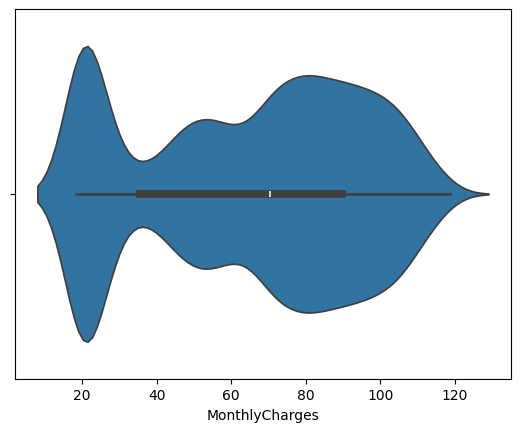

In [ ]:
sns.violinplot(x = df['MonthlyCharges'])

In [ ]:
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [ ]:
df['TotalCharges'] = df['TotalCharges'].replace(' ',0).astype(float)

4. Feature Engineering and Feature Selection

In [ ]:
cols = ['TotalCharges','gender','Dependents','Partner','PhoneService','customerID','DeviceProtection','StreamingMovies']
df.drop(columns=cols,axis=1,inplace=True)

In [ ]:
df.shape

(7043, 13)

In [ ]:
df['tenure'].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26,  0, 39])

In [ ]:
df.columns

Index(['SeniorCitizen', 'tenure', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'TechSupport', 'StreamingTV',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'Churn'],
      dtype='object')

**Feature Engineering**

1. **tenure_group** :
Customer tenure was transformed into groups to capture different stages of the customer lifecycle.

This helps the model distinguish between:

New customers Early-stage customers Long-term customers

2. **high_risk** : A custom high-risk indicator was created using two churn-related conditions:
1 → High-risk combination 0 → Otherwise

This allows the model to capture an interaction that may otherwise be harder to learn from the individual variables alone.

3. **Senior_Pressure** : Another engineered feature combines monthly charges with senior-citizen status:

Senior_Pressure = Monthly_charges × SeniorCitizen

This feature captures the idea that higher monthly charges may have a different implication for senior customers than for non-senior customers.

In [ ]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[-1,6,12,24,73],
    labels=['0-6 months','6-12 months','1-2 years','2+ years']
)

df['high_risk'] = ((df['tenure'] <= 6) & (df['TechSupport'] == 'No')).astype(int)

df['Senior_Pressure'] = df['MonthlyCharges'] * df['SeniorCitizen']

In [ ]:
df.drop('SeniorCitizen',axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   tenure            7043 non-null   int64   
 1   MultipleLines     7043 non-null   object  
 2   InternetService   7043 non-null   object  
 3   OnlineSecurity    7043 non-null   object  
 4   OnlineBackup      7043 non-null   object  
 5   TechSupport       7043 non-null   object  
 6   StreamingTV       7043 non-null   object  
 7   Contract          7043 non-null   object  
 8   PaperlessBilling  7043 non-null   object  
 9   PaymentMethod     7043 non-null   object  
 10  MonthlyCharges    7043 non-null   float64 
 11  Churn             7043 non-null   object  
 12  tenure_group      7043 non-null   category
 13  high_risk         7043 non-null   int64   
 14  Senior_Pressure   7043 non-null   float64 
dtypes: category(1), float64(2), int64(2), object(10)
memory usage: 777.5+ KB

In [ ]:
df.describe()

,tenure,MonthlyCharges,high_risk,Senior_Pressure
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,0.137725,12.942617
std,24.559481,30.090047,0.344636,30.938612
min,0.000000,18.250000,0.000000,0.000000
25%,9.000000,35.500000,0.000000,0.000000
50%,29.000000,70.350000,0.000000,0.000000
75%,55.000000,89.850000,0.000000,0.000000
max,72.000000,118.750000,1.000000,117.450000


More Analysis

In [ ]:
print(df['tenure'].skew())
print(df['MonthlyCharges'].skew())
print(df['Senior_Pressure'].skew())

0.2395397495619829
-0.22052443394398033
2.1305640368417698


<Axes: ylabel='Senior_Pressure'>

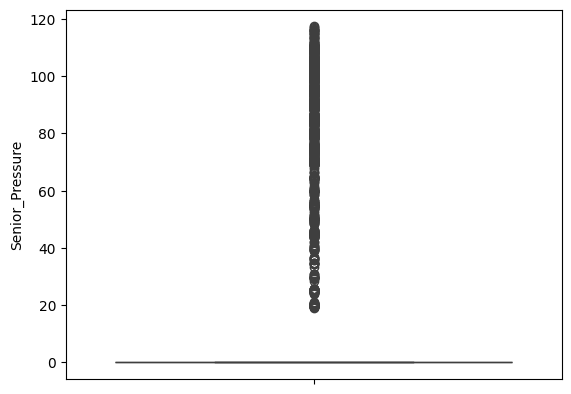

In [ ]:
sns.boxplot(df['Senior_Pressure'])

/tmp/ipykernel_279/3061132571.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Senior_Pressure'])


<Axes: xlabel='Senior_Pressure', ylabel='Density'>

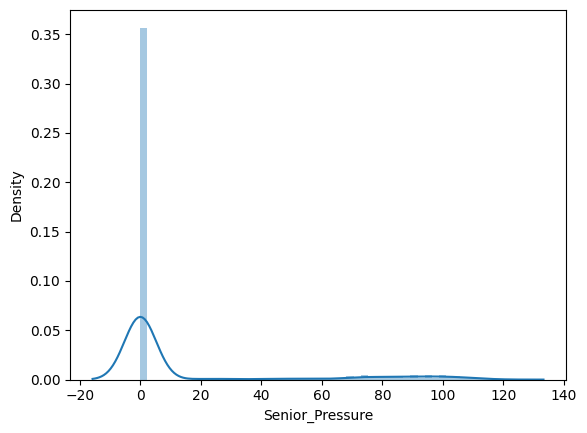

In [ ]:
sns.distplot(df['Senior_Pressure'])

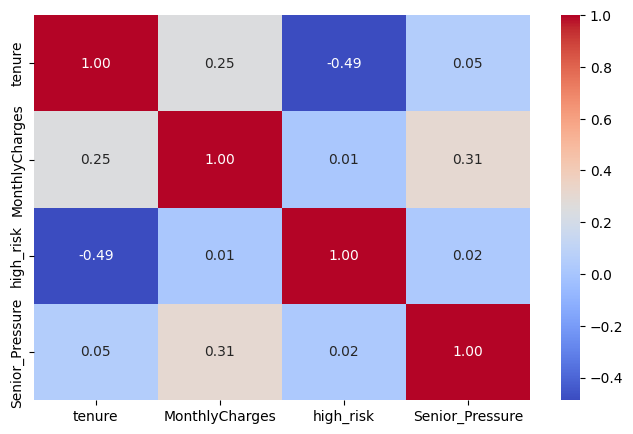

In [ ]:
plt.figure(figsize=(8,5))
corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt=".2f")
plt.show()

In [ ]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [ ]:
df['Churn'] = df['Churn'].replace({'Yes' : 1 , 'No' : 0})

/tmp/ipykernel_1301/1103342330.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'Yes' : 1 , 'No' : 0})


In [ ]:
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


6. Splitting the data into training and testing

In [ ]:
X = df.drop('Churn',axis=1)
Y = df['Churn']

#📖**Version A : Using Class Weights to handle Imbalanced data without synthetic over sampling**

In [ ]:
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size=0.1,random_state=42)

In [ ]:
Y_train.value_counts()

,count
Churn,
0,4663
1,1675


In [ ]:
X_train.head(3)

,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,TechSupport,StreamingTV,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,tenure_group,high_risk,Senior_Pressure
1554,26,No,No,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.90,2+ years,0,0.00
4817,1,No,No,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.90,0-6 months,0,0.00
5957,18,No,Fiber optic,No,No,No,No,Month-to-month,No,Electronic check,78.55,1-2 years,0,78.55


7. Data Preprocessing

In [ ]:
num = ['tenure','MonthlyCharges','Senior_Pressure']
cat = ['tenure_group','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','TechSupport','StreamingTV','Contract','PaperlessBilling','PaymentMethod']

In [ ]:
processor = ColumnTransformer(
    transformers = [
        ('scaler',StandardScaler(),num),
        ('encoder',OrdinalEncoder(dtype=int),cat)
    ],
    remainder = 'passthrough'
)

In [ ]:
X_train_tran = processor.fit_transform(X_train)
X_test_tran = processor.transform(X_test)

In [ ]:
names = processor.get_feature_names_out()
X_train_new = pd.DataFrame(X_train_tran,columns=names,index=X_train.index)
X_test_new = pd.DataFrame(X_test_tran,columns=names,index=X_test.index)

In [ ]:
X_train_new

,scaler__tenure,scaler__MonthlyCharges,scaler__Senior_Pressure,encoder__tenure_group,encoder__MultipleLines,encoder__InternetService,encoder__OnlineSecurity,encoder__OnlineBackup,encoder__TechSupport,encoder__StreamingTV,encoder__Contract,encoder__PaperlessBilling,encoder__PaymentMethod,remainder__high_risk
1554,-0.259164,-1.453080,-0.417996,2.0,0.0,2.0,1.0,1.0,1.0,1.0,0.0,0.0,3.0,0.0
4817,-1.278108,-1.486260,-0.417996,0.0,0.0,2.0,1.0,1.0,1.0,1.0,0.0,0.0,3.0,0.0
5957,-0.585226,0.459751,2.125589,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
5123,-0.707499,0.351916,2.020348,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,1.0,0.0
3217,-1.237350,-1.468011,-0.417996,0.0,0.0,2.0,1.0,1.0,1.0,1.0,0.0,1.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,-1.278108,1.005563,-0.417996,0.0,0.0,1.0,2.0,0.0,0.0,2.0,0.0,1.0,2.0,1.0
5191,-0.381437,0.876161,-0.417996,1.0,2.0,0.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,0.0
5226,-0.829772,-1.444785,-0.417996,3.0,0.0,2.0,1.0,1.0,1.0,1.0,0.0,1.0,2.0,0.0
5390,-0.829772,1.153214,2.802367,3.0,2.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0,2.0,0.0


In [ ]:
cat_features = [col for col in X_train_new.columns if (col.startswith('encoder_') or col.startswith('remainder_'))]
X_train_new[cat_features] = X_train_new[cat_features].astype(int)
X_test_new[cat_features] = X_test_new[cat_features].astype(int)

In [ ]:
X_train_new

,scaler__tenure,scaler__MonthlyCharges,scaler__Senior_Pressure,encoder__tenure_group,encoder__MultipleLines,encoder__InternetService,encoder__OnlineSecurity,encoder__OnlineBackup,encoder__TechSupport,encoder__StreamingTV,encoder__Contract,encoder__PaperlessBilling,encoder__PaymentMethod,remainder__high_risk
1554,-0.259164,-1.453080,-0.417996,2,0,2,1,1,1,1,0,0,3,0
4817,-1.278108,-1.486260,-0.417996,0,0,2,1,1,1,1,0,0,3,0
5957,-0.585226,0.459751,2.125589,1,0,1,0,0,0,0,0,0,2,0
5123,-0.707499,0.351916,2.020348,1,0,1,0,2,0,0,0,1,1,0
3217,-1.237350,-1.468011,-0.417996,0,0,2,1,1,1,1,0,1,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,-1.278108,1.005563,-0.417996,0,0,1,2,0,0,2,0,1,2,1
5191,-0.381437,0.876161,-0.417996,1,2,0,2,2,2,2,2,1,1,0
5226,-0.829772,-1.444785,-0.417996,3,0,2,1,1,1,1,0,1,2,0
5390,-0.829772,1.153214,2.802367,3,2,1,0,0,0,2,0,1,2,0


#Model Training : Version A

In [ ]:
models = {
    'Logistic Regression' : LogisticRegression(class_weight='balanced',penalty='l2',random_state=42),
    'Decision Tree' : DecisionTreeClassifier(class_weight='balanced',max_depth=6,min_samples_leaf=6,max_features='sqrt',random_state=42),
    'KNN' : KNeighborsClassifier(weights='distance',n_neighbors=15),
    'SVM' : SVC(class_weight='balanced',C=0.7,random_state=42),
    'RF' : RandomForestClassifier(n_estimators=150,class_weight='balanced',max_depth=8,min_samples_leaf=5,max_features='sqrt',random_state=42),
    'XGB' : XGBClassifier(n_estimators=150,scale_pos_weight=1.68,max_depth=5,learning_rate=0.06,colsample_bytree=0.6,subsample=0.75,reg_lambda=2.57,random_state=42)
}

for name , model in models.items() :
  model.fit(X_train_new,Y_train)
  print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
KNN trained successfully.
SVM trained successfully.
RF trained successfully.
XGB trained successfully.


# Model Prediction

In [ ]:
for name,model in models.items() :
  Y_pred = model.predict(X_test_new)
  print(f"{name} metrics : \n")
  print(f"Training score = {model.score(X_train_new,Y_train)}")
  print(f"Testing score = {model.score(X_test_new,Y_test)}")
  print("Classification Report : ")
  print(classification_report(Y_test,Y_pred))
  print("\n")
  print(confusion_matrix(Y_test,Y_pred))
  if name != 'SVM' :
    prob = model.predict_proba(X_test_new)[:,1]
    print(f"PR-AUC score : {average_precision_score(Y_test,prob)}")
    print(f"ROC score = {roc_auc_score(Y_test,prob)}")

Logistic Regression metrics : 

Training score = 0.7483433259703376
Testing score = 0.7659574468085106
Classification Report : 
              precision    recall  f1-score   support

           0       0.91      0.75      0.82       511
           1       0.55      0.80      0.65       194

    accuracy                           0.77       705
   macro avg       0.73      0.78      0.74       705
weighted avg       0.81      0.77      0.78       705



[[384 127]
 [ 38 156]]
PR-AUC score : 0.6879354134074798
ROC score = 0.8646579377408357
Decision Tree metrics : 

Training score = 0.7627011675607447
Testing score = 0.7787234042553192
Classification Report : 
              precision    recall  f1-score   support

           0       0.90      0.78      0.84       511
           1       0.57      0.77      0.66       194

    accuracy                           0.78       705
   macro avg       0.74      0.78      0.75       705
weighted avg       0.81      0.78      0.79       705



[[40

#Feature Importance from the best performing models

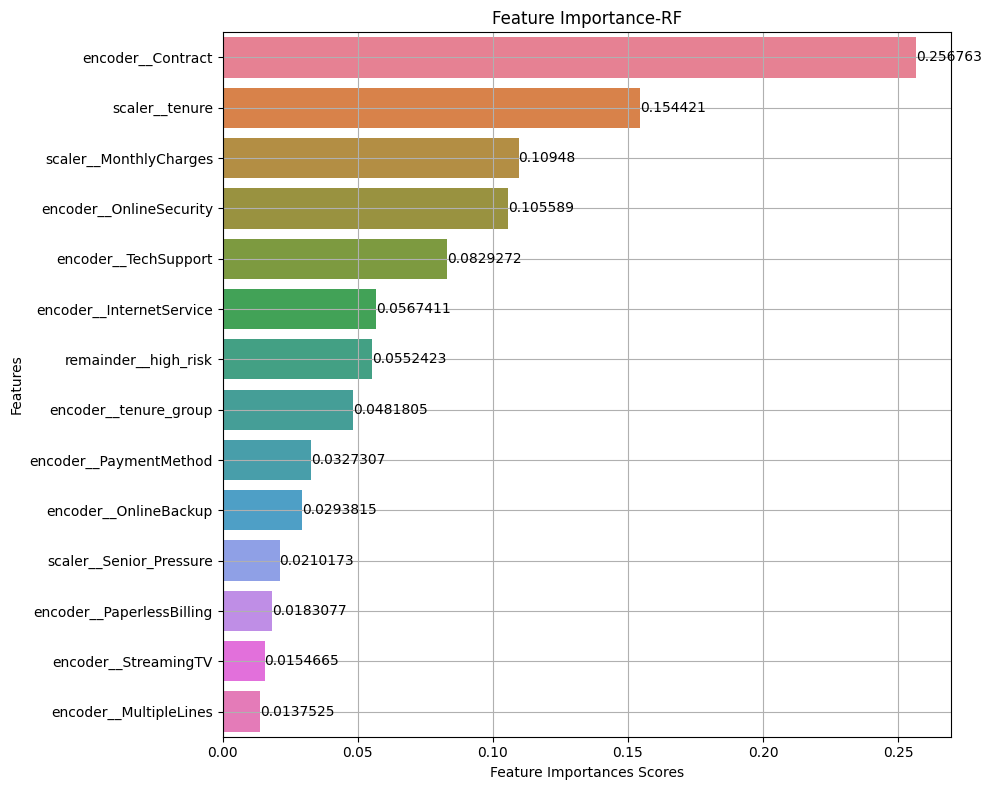

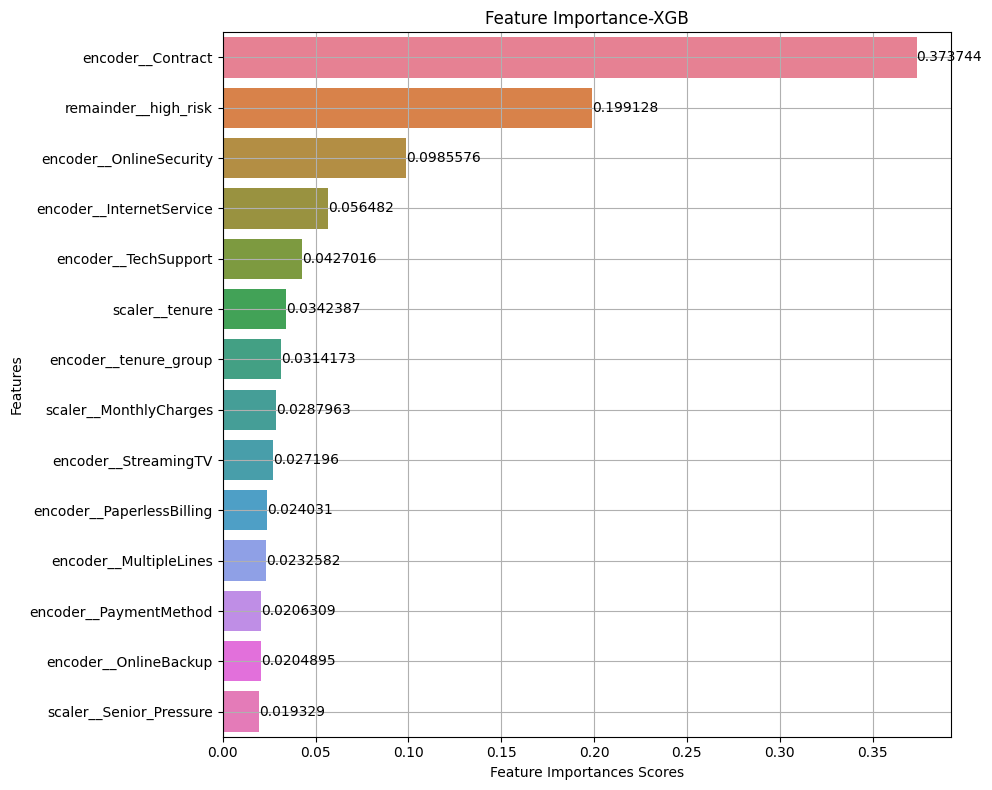

In [ ]:
for m_name,Models in models.items() :
    feature_importances = models[m_name].feature_importances_
    feature_names = X_train_new.columns
    importance_df = pd.DataFrame({
      'feature' : feature_names,
      'importance' : feature_importances
    }).sort_values('importance',ascending=False)
    plt.figure(figsize=(10,8))
    plot = sns.barplot(data=importance_df,y='feature',x='importance',hue='feature')
    for i in plot.containers :
      plot.bar_label(i)
    plt.grid()
    plt.title(f"Feature Importance-{m_name}")
    plt.xlabel("Feature Importances Scores")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

In [ ]:
X_train_new.shape

(6338, 14)

#Training an ANN(Artificial Neural Network)

In [ ]:
ann = Sequential()
ann.add(Dense(64,input_dim=14,activation="relu",kernel_regularizer=L2()))
ann.add(BatchNormalization())
ann.add(Dense(32,activation="relu",kernel_regularizer=L2()))
ann.add(BatchNormalization())
ann.add(Dense(16,activation="relu",kernel_regularizer=L2()))
ann.add(BatchNormalization())
ann.add(Dense(1,activation='sigmoid'))

ann.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ANN = ann.fit(X_train_new,Y_train,batch_size=200,epochs=20,validation_data=[X_test_new,Y_test],callbacks=EarlyStopping(patience=3,restore_best_weights=True))

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8159 - loss: 0.6322 - val_accuracy: 0.7915 - val_loss: 0.6767
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8152 - loss: 0.6068 - val_accuracy: 0.7929 - val_loss: 0.6522
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8105 - loss: 0.5898 - val_accuracy: 0.7887 - val_loss: 0.6351
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8171 - loss: 0.5683 - val_accuracy: 0.7801 - val_loss: 0.6186
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8176 - loss: 0.5510 - val_accuracy: 0.7759 - val_loss: 0.5986
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8162 - loss: 0.5340 - val_accuracy: 0.7887 - val_loss: 0.5817
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8238 - loss: 0.5255 - val_accuracy: 0.7972 - val_loss: 0.5690
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8176 - loss: 0.5139 - val_accuracy: 0.7972 - v

In [ ]:
ann.evaluate(X_test_new,Y_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8014 - loss: 0.4936


[0.4936116933822632, 0.8014184236526489]

In [ ]:
Y_pred = ann.predict(X_test_new)
prediction = (Y_pred > 0.5).astype(int)
print(classification_report(Y_test,prediction,target_names=['Class 0','Class 1']))
print(confusion_matrix(Y_test,prediction))

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
              precision    recall  f1-score   support

     Class 0       0.84      0.90      0.87       511
     Class 1       0.68      0.53      0.60       194

    accuracy                           0.80       705
   macro avg       0.76      0.72      0.73       705
weighted avg       0.79      0.80      0.79       705

[[462  49]
 [ 91 103]]


#Performing Hyperparameter tuning the best models

In [ ]:
RFgrid = {
    'n_estimators' : randint(150,300),
    'max_depth' : [8,10,12,15],
    'min_samples_split' : [2,5,10],
    'min_samples_leaf' : [2,4,6],
    'max_features' : ['sqrt','log2',0.7],
    'criterion' : ['gini','entropy','log_loss'],
    'class_weight' : ['balanced','balanced_subsample',None]
}

value = (Y_train == 0).sum()/(Y_train == 1).sum()
XGB_grid = {
    'n_estimators' : randint(100,300),
    'scale_pos_weight' : [1,1.1,1.2,1.3,1.4,1.5,1.7,1.8,value],
    'learning_rate' : [0.01,0.03,0.05,0.08,0.1],
    'max_depth' : [3,4,5,6],
    'reg_lambda' : [1,1.5,2],
    'reg_alpha' : [0,0.1,1],
    'gamma' : [0,0.1,0.2],
    'subsample' : [0.7,0.8,0.9],
    'colsample_bytree' : [0.6,0.7,0.8]
}

In [ ]:
RFsearch = RandomizedSearchCV(estimator=models['RF'],param_distributions=RFgrid,cv=5,n_jobs=-1,scoring='roc_auc',n_iter=40,random_state=42)
RFsearch.fit(X_train_new,Y_train)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    max_depth=8,
                                                    min_samples_leaf=5,
                                                    n_estimators=150,
                                                    random_state=42),
                   n_iter=40, n_jobs=-1,
                   param_distributions={'class_weight': ['balanced',
                                                         'balanced_subsample',
                                                         None],
                                        'criterion': ['gini', 'entropy',
                                                      'log_loss'],
                                        'max_depth': [8, 10, 12, 15],
                                        'max_features': ['sqrt', 'log2', 0.7],
                                        'min_samples_leaf': [2, 4, 6],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a541412fc50>},
                   random_state=42, scoring='roc_auc')

In [ ]:
RFsearch.best_params_

{'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': 8,
 'max_features': 'sqrt',
 'min_samples_leaf': 6,
 'min_samples_split': 2,
 'n_estimators': 151}

In [ ]:
random_search_xgb = RandomizedSearchCV(estimator=models['XGB'],param_distributions=XGB_grid,cv=10,n_iter=75,scoring='roc_auc',n_jobs=-1,random_state=42)
random_search_xgb.fit(X_train_new,Y_train)

RandomizedSearchCV(cv=10,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=0.7, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraint...
                                        'gamma': [0, 0.1, 0.2],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.08, 0.1],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a541688eae0>,
                                        'reg_alpha': [0, 0.1, 1],
                                        'reg_lambda': [1, 1.5, 2],
                                        'scale_pos_weight': [1, 1.1, 1.2, 1.3,
                                                             1.4, 1.5, 1.7, 1.8,
                                                             np.float64(2.7838805970149254)],
                                        'subsample': [0.7, 0.8, 0.9]},
                   random_state=42, scoring='roc_auc')

In [ ]:
random_search_xgb.best_params_

{'colsample_bytree': 0.6,
 'gamma': 0.1,
 'learning_rate': 0.03,
 'max_depth': 4,
 'n_estimators': 153,
 'reg_alpha': 1,
 'reg_lambda': 1,
 'scale_pos_weight': np.float64(2.7838805970149254),
 'subsample': 0.7}

#Re-Training the best models with tuned parmeters

In [ ]:
newbest_models = {
    'Random Forest' : RandomForestClassifier(n_estimators= 151,min_samples_split= 2,min_samples_leaf= 6,
                                             max_features= 'sqrt',max_depth= 8,criterion= 'gini', class_weight= 'balanced'),
    'XGBoost' : XGBClassifier(n_estimators=153,scale_pos_weight=2.8,learning_rate=0.03,colsample_bytree=0.6,max_depth=4,gamma=0.1,
                              reg_alpha=1,reg_lambda=1,subsample=0.7,random_state=42)
}

for name , model in newbest_models.items() :
  model.fit(X_train_new,Y_train)
  print(f"{name} trained successfully.")

Random Forest trained successfully.
XGBoost trained successfully.


In [ ]:
for Name,Model in newbest_models.items() :
  newpred = Model.predict(X_test_new)
  prob = Model.predict_proba(X_test_new)[:,1]
  new_pred =  (prob >= 0.63).astype(int)
  print(f"{Name} metrics : \n")
  print(f"Training score = {Model.score(X_train_new,Y_train)}")
  print(f"Testing score = {Model.score(X_test_new,Y_test)}")
  print("Classification Report before threshold: ")
  print(classification_report(Y_test,newpred))
  print("\n")
  print("Classification Report After threshold: ")
  print(classification_report(Y_test,new_pred))
  print(f"PR-AUC = {average_precision_score(Y_test,prob)}")
  print(f"ROC score = {roc_auc_score(Y_test,prob)}")
  print("\n")
  print(confusion_matrix(Y_test,new_pred))

Random Forest metrics : 

Training score = 0.7871568318081413
Testing score = 0.775886524822695
Classification Report before threshold: 
              precision    recall  f1-score   support

           0       0.92      0.76      0.83       511
           1       0.56      0.81      0.67       194

    accuracy                           0.78       705
   macro avg       0.74      0.79      0.75       705
weighted avg       0.82      0.78      0.79       705



Classification Report After threshold: 
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       511
           1       0.66      0.66      0.66       194

    accuracy                           0.81       705
   macro avg       0.77      0.77      0.77       705
weighted avg       0.81      0.81      0.81       705

PR-AUC = 0.7109886898173252
ROC score = 0.8729447011116267


[[446  65]
 [ 66 128]]
XGBoost metrics : 

Training score = 0.763805616913853
Testing score = 0.7687943262

In [ ]:
X_train_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6338 entries, 1554 to 860
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   scaler__tenure             6338 non-null   float64
 1   scaler__MonthlyCharges     6338 non-null   float64
 2   scaler__Senior_Pressure    6338 non-null   float64
 3   encoder__tenure_group      6338 non-null   int64  
 4   encoder__MultipleLines     6338 non-null   int64  
 5   encoder__InternetService   6338 non-null   int64  
 6   encoder__OnlineSecurity    6338 non-null   int64  
 7   encoder__OnlineBackup      6338 non-null   int64  
 8   encoder__TechSupport       6338 non-null   int64  
 9   encoder__StreamingTV       6338 non-null   int64  
 10  encoder__Contract          6338 non-null   int64  
 11  encoder__PaperlessBilling  6338 non-null   int64  
 12  encoder__PaymentMethod     6338 non-null   int64  
 13  remainder__high_risk       6338 non-null   int64  


#📖Version B : Using SMOTE for over-sampling Imbalanced data


In [ ]:
x_train = X_train_new.copy()
y_train = Y_train.copy()
x_test = X_test_new.copy()
y_test = Y_test.copy()

In [ ]:
x_train

,scaler__tenure,scaler__MonthlyCharges,scaler__Senior_Pressure,encoder__tenure_group,encoder__MultipleLines,encoder__InternetService,encoder__OnlineSecurity,encoder__OnlineBackup,encoder__TechSupport,encoder__StreamingTV,encoder__Contract,encoder__PaperlessBilling,encoder__PaymentMethod,remainder__high_risk
1554,-0.259164,-1.453080,-0.417996,2,0,2,1,1,1,1,0,0,3,0
4817,-1.278108,-1.486260,-0.417996,0,0,2,1,1,1,1,0,0,3,0
5957,-0.585226,0.459751,2.125589,1,0,1,0,0,0,0,0,0,2,0
5123,-0.707499,0.351916,2.020348,1,0,1,0,2,0,0,0,1,1,0
3217,-1.237350,-1.468011,-0.417996,0,0,2,1,1,1,1,0,1,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,-1.278108,1.005563,-0.417996,0,0,1,2,0,0,2,0,1,2,1
5191,-0.381437,0.876161,-0.417996,1,2,0,2,2,2,2,2,1,1,0
5226,-0.829772,-1.444785,-0.417996,3,0,2,1,1,1,1,0,1,2,0
5390,-0.829772,1.153214,2.802367,3,2,1,0,0,0,2,0,1,2,0


Doing Over Sampling using SMOTE

In [ ]:
smote = SMOTE(random_state=42)
x_train_res,y_train_res = smote.fit_resample(x_train,y_train)

In [ ]:
x_train_res.shape

(9326, 14)

In [ ]:
y_train_res.value_counts()

,count
Churn,
0,4663
1,4663


In [ ]:
x_train_res.tail()

,scaler__tenure,scaler__MonthlyCharges,scaler__Senior_Pressure,encoder__tenure_group,encoder__MultipleLines,encoder__InternetService,encoder__OnlineSecurity,encoder__OnlineBackup,encoder__TechSupport,encoder__StreamingTV,encoder__Contract,encoder__PaperlessBilling,encoder__PaymentMethod,remainder__high_risk
9321,-0.985168,0.700880,-0.417996,3,2,1,0,0,0,2,0,1,2,0
9322,0.630389,0.818302,2.475513,2,2,1,0,2,0,0,0,0,0,0
9323,-0.393239,0.853806,-0.417996,1,2,1,0,0,2,2,0,1,2,0
9324,-1.254424,0.169313,-0.417996,0,0,1,0,0,0,0,0,0,2,1
9325,-0.662517,1.076105,-0.417996,1,2,1,0,2,0,2,0,0,2,0


#Model Training : Version B

In [ ]:
base_models = {
    'Logistic Regression' : LogisticRegression(penalty='l2',random_state=42),
    'Decision Tree' : DecisionTreeClassifier(max_depth=6,min_samples_leaf=6,random_state=42),
    'Random Forest' : RandomForestClassifier(n_estimators=150,max_depth=5,min_samples_split=8,random_state=42),
    'KNN' : KNeighborsClassifier(weights='distance'),
    'SVM' : SVC(C=0.75,random_state=42),
    'XGBoost' : XGBClassifier(n_estimators=150,max_depth=5,learning_rate=0.05,colsample_bytree=0.6,subsample=0.7,reg_lambda=5,random_state=42)
}

#Train Models
for name , model in base_models.items() :
  model.fit(x_train_res,y_train_res)
  print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
KNN trained successfully.
SVM trained successfully.
XGBoost trained successfully.


#Model Prediction

In [ ]:
for name,model in base_models.items() :
  prediction = model.predict(x_test)
  print(f"{name} metrics : \n")
  print(f"Training score = {model.score(x_train_res,y_train_res)}")
  print(f"Testing score = {model.score(x_test,y_test)}")
  print("Classification Report : ")
  print(classification_report(y_test,prediction))
  print(confusion_matrix(y_test,prediction))

Logistic Regression metrics : 

Training score = 0.7610980055758095
Testing score = 0.7645390070921986
Classification Report : 
              precision    recall  f1-score   support

           0       0.91      0.75      0.82       511
           1       0.55      0.81      0.66       194

    accuracy                           0.76       705
   macro avg       0.73      0.78      0.74       705
weighted avg       0.81      0.76      0.78       705

[[381 130]
 [ 36 158]]
Decision Tree metrics : 

Training score = 0.785331331760669
Testing score = 0.7588652482269503
Classification Report : 
              precision    recall  f1-score   support

           0       0.89      0.76      0.82       511
           1       0.55      0.75      0.63       194

    accuracy                           0.76       705
   macro avg       0.72      0.76      0.73       705
weighted avg       0.79      0.76      0.77       705

[[390 121]
 [ 49 145]]
Random Forest metrics : 

Training score = 0.781149

#Training an ANN(Artificial Neural Network) : Version B

In [ ]:
ann1 = Sequential()
ann1.add(Dense(64,input_dim=14,activation="relu",kernel_regularizer=L2()))
ann1.add(BatchNormalization())
ann1.add(Dense(32,activation="relu",kernel_regularizer=L2()))
ann1.add(BatchNormalization())
ann1.add(Dense(16,activation="relu",kernel_regularizer=L2()))
ann1.add(BatchNormalization())
ann1.add(Dense(1,activation='sigmoid'))

ann1.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ANN1 = ann1.fit(x_train_res,y_train_res,batch_size=200,epochs=20,validation_data=[x_test,y_test],callbacks=EarlyStopping(patience=3,restore_best_weights=True))

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.7161 - loss: 1.3917 - val_accuracy: 0.7688 - val_loss: 1.2827
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7576 - loss: 1.1829 - val_accuracy: 0.7844 - val_loss: 1.1411
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7714 - loss: 1.0419 - val_accuracy: 0.7915 - val_loss: 1.0260
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7757 - loss: 0.9301 - val_accuracy: 0.7915 - val_loss: 0.9427
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7850 - loss: 0.8413 - val_accuracy: 0.7773 - val_loss: 0.8834
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7866 - loss: 0.7743 - val_accuracy: 0.7574 - val_loss: 0.8325
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7900 - loss: 0.7211 - val_accuracy: 0.7759 - val_loss: 0.7739
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7974 - loss: 0.6765 - val_accuracy: 0.7603 - val_lo

In [ ]:
y_pred = ann1.predict(x_test)
pred = (y_pred > 0.5).astype(int)
print(classification_report(y_test,pred,target_names=['Class 0','Class 1']))
print(confusion_matrix(y_test,pred))

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
              precision    recall  f1-score   support

     Class 0       0.90      0.69      0.78       511
     Class 1       0.49      0.79      0.60       194

    accuracy                           0.71       705
   macro avg       0.69      0.74      0.69       705
weighted avg       0.78      0.71      0.73       705

[[351 160]
 [ 41 153]]


#Best Model : XGBoost(Version A)

  **Accuracy ~ 82%**

  **Precision ~ 67%**

  **Recall ~ 72%**

  **F1-Score ~ 69%**

  **PR-AUC ~ 70%**
  
  **ROC ~ 87%**

#📊Confusion Matrix Plot of the best model : Version A(XGBoost)

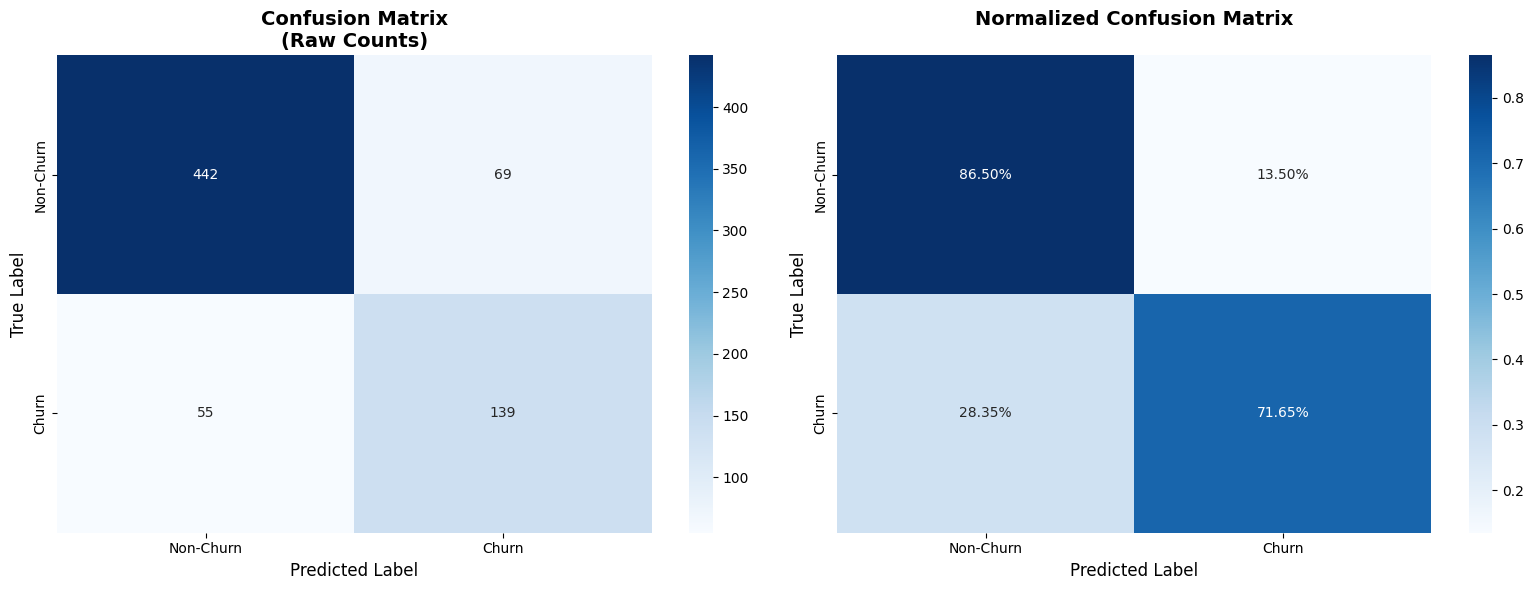

In [ ]:
ypred = models['XGB'].predict(X_test_new)

class_names = ['Non-Churn','Churn']
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,6))

cm1 = confusion_matrix(Y_test,ypred)
sns.heatmap(cm1,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names,ax=ax1)
ax1.set_title("Confusion Matrix\n(Raw Counts)",fontsize=14,fontweight='bold')
ax1.set_ylabel("True Label",fontsize=12)
ax1.set_xlabel("Predicted Label",fontsize=12)

cm2 = confusion_matrix(Y_test,ypred,normalize='true')
sns.heatmap(cm2,annot=True,fmt='.2%',cmap='Blues',xticklabels=class_names,yticklabels=class_names,ax=ax2)
ax2.set_title("Normalized Confusion Matrix\n",fontsize=14,fontweight='bold')
ax2.set_ylabel("True Label",fontsize=12)
ax2.set_xlabel("Predicted Label",fontsize=12)

plt.tight_layout()
plt.show()

#🚀**Conclusion**

**This project demonstrates an end-to-end approach to customer churn prediction,from aggressive feature selection and domain-driven feature-engineering to EDA,model comparison,hyperparameter tuning, and final model selection.**